# Calculate the daily fees

In [1]:
import pdfplumber
import pandas as pd

PDF_PATH = r"D:\PC DISAINE\toky\Perso-D\red\momo\transaction-history-20260723_092532624.pdf"  # change to your file path
DATE = "2026-07-22"
START_BALANCE = 330269
END_BALANCE = 550300

all_tables = []

with pdfplumber.open(PDF_PATH) as pdf:
    for i, page in enumerate(pdf.pages):
        table = page.extract_table()
        if table:
            print(f"Page {i+1}: found table with {len(table)-1} rows")
            all_tables.append(table)

# Use first table found, or merge all
raw = all_tables[0]
df = pd.DataFrame(raw[1:], columns=raw[0])  # row 0 = headers
df.head()

Page 1: found table with 15 rows
Page 2: found table with 20 rows
Page 3: found table with 20 rows
Page 4: found table with 21 rows
Page 5: found table with 20 rows
Page 6: found table with 20 rows
Page 7: found table with 6 rows


,Transaction\nId,Status,Transaction Type,Date,From,To,Amount (RWF),Fee\n(RWF),Balance\nAfter (RWF)
0,29370168848,SUCCESSFUL,PAYMENT,2026-07-22 22:03:36,250788303656\nAnicet MUNYEHIRWE,38998332\nRED IKIRWA FLAVOURS\nLtd RED IKIRWA\...,8000,N/A,550300
1,29367618302,SUCCESSFUL,PAYMENT,2026-07-22 19:57:38,250791701696\nLaetitia UMUBYEYI,38998332\nRED IKIRWA FLAVOURS\nLtd RED IKIRWA\...,11000,N/A,542340
2,29367052344,SUCCESSFUL,PAYMENT,2026-07-22 19:39:02,250793147885\nRANAIVOSON ONITSIKY,38998332\nRED IKIRWA FLAVOURS\nLtd RED IKIRWA\...,1000,N/A,531395
3,29366737659,SUCCESSFUL,PAYMENT,2026-07-22 19:29:32,250785460999\nValery BIZIMANA,38998332\nRED IKIRWA FLAVOURS\nLtd RED IKIRWA\...,6500,N/A,530395
4,29366707208,SUCCESSFUL,PAYMENT,2026-07-22 19:28:34,250795573441\nRED IKIRWA FLAVOURS\nLtd,22539293\nBlessed Dairies Ltd Blessed\nDairies...,70800,0,523927


# Clean raw tabular data

In [2]:
headers = all_tables[0][0]
frames = []

for t in all_tables:
    rows = [row for row in t if row != headers]  # drop repeated header rows
    frames.append(pd.DataFrame(rows, columns=headers))

df = pd.concat(frames, ignore_index=True)

df = df.replace("", pd.NA)
df = df.dropna(how="any")

df = df.rename(columns={'Amount\n(RWF)': 'Amount (RWF)'})

df['Amount (RWF)'] = df['Amount (RWF)'].astype(int)

df.shape

(118, 9)

In [3]:
df["Date"] = pd.to_datetime(df["Date"], format="%Y-%m-%d %H:%M:%S")
start = pd.to_datetime(f"{DATE} 00:00:00")
end   = pd.to_datetime(f"{DATE} 23:59:59")

df_subset = df[(df["Date"] >= start) & (df["Date"] <= end)]
df_subset

,Transaction\nId,Status,Transaction Type,Date,From,To,Amount (RWF),Fee\n(RWF),Balance\nAfter (RWF)
0,29370168848,SUCCESSFUL,PAYMENT,2026-07-22 22:03:36,250788303656\nAnicet MUNYEHIRWE,38998332\nRED IKIRWA FLAVOURS\nLtd RED IKIRWA\...,8000,N/A,550300
1,29367618302,SUCCESSFUL,PAYMENT,2026-07-22 19:57:38,250791701696\nLaetitia UMUBYEYI,38998332\nRED IKIRWA FLAVOURS\nLtd RED IKIRWA\...,11000,N/A,542340
2,29367052344,SUCCESSFUL,PAYMENT,2026-07-22 19:39:02,250793147885\nRANAIVOSON ONITSIKY,38998332\nRED IKIRWA FLAVOURS\nLtd RED IKIRWA\...,1000,N/A,531395
3,29366737659,SUCCESSFUL,PAYMENT,2026-07-22 19:29:32,250785460999\nValery BIZIMANA,38998332\nRED IKIRWA FLAVOURS\nLtd RED IKIRWA\...,6500,N/A,530395
4,29366707208,SUCCESSFUL,PAYMENT,2026-07-22 19:28:34,250795573441\nRED IKIRWA FLAVOURS\nLtd,22539293\nBlessed Dairies Ltd Blessed\nDairies...,70800,0,523927
5,29366058238,SUCCESSFUL,PAYMENT,2026-07-22 19:10:14,250788589341\nMugwaneza Benigne\nISHIMWE,38998332\nRED IKIRWA FLAVOURS\nLtd RED IKIRWA\...,14000,N/A,594727
6,29364830504,SUCCESSFUL,PAYMENT,2026-07-22 18:37:28,250788769481\nMadeleine MARARA,38998332\nRED IKIRWA FLAVOURS\nLtd RED IKIRWA\...,11500,N/A,580797
7,29364276908,SUCCESSFUL,PAYMENT,2026-07-22 18:23:03,250788317383\nJean Claude NSABIMANA,38998332\nRED IKIRWA FLAVOURS\nLtd RED IKIRWA\...,3000,N/A,569354
8,29364163108,SUCCESSFUL,PAYMENT,2026-07-22 18:19:07,250792400095\nMATLALA LEBOGANG\nKGOSITSILE NGWATO,38998332\nRED IKIRWA FLAVOURS\nLtd RED IKIRWA\...,20500,N/A,566369
9,29362856935,SUCCESSFUL,PAYMENT,2026-07-22 17:36:41,250788352713\nJean Nepo\nUTUMATWISHIMA,38998332\nRED IKIRWA FLAVOURS\nLtd RED IKIRWA\...,7000,N/A,545971


# Calculate the sum of all transactions

In [16]:
# Assign +/- sign based on the type column
df_subset["Signed Amount"] = df_subset["Amount (RWF)"].where(df_subset["Transaction Type"] == "PAYMENT", -df_subset["Amount (RWF)"])

# Then sum
total_transactions = df_subset["Signed Amount"].sum()
print("Total transactions:", total_transactions)

Total transactions: 363100


## Total fees

In [14]:
total_actual_transactions = END_BALANCE - START_BALANCE
print("Total transactions - fees =" , total_actual_transactions)

Total transactions - fees = 220031


In [17]:
error = 141600
total_fees = total_transactions - total_actual_transactions - error

print("Total fees:", total_fees)

Total fees: 1469


# Check individual transaction fee

In [7]:
df_subset = df_subset.rename(columns={'Balance\nAfter (RWF)': 'Balance'})
df_subset["Balance"] = df_subset["Balance"].astype("int")

In [8]:
df_subset["transaction_fee"] = df_subset["Amount (RWF)"] - ( df_subset["Balance"] - df_subset["Balance"].shift(-1) )


In [9]:
total = df_subset.loc[(df_subset["transaction_fee"] >= 0) & (df_subset["transaction_fee"] <= 3000), "transaction_fee"].sum()
print(total)

1429.0


In [10]:
df_subset

,Transaction\nId,Status,Transaction Type,Date,From,To,Amount (RWF),Fee\n(RWF),Balance,Signed Amount,transaction_fee
0,29370168848,SUCCESSFUL,PAYMENT,2026-07-22 22:03:36,250788303656\nAnicet MUNYEHIRWE,38998332\nRED IKIRWA FLAVOURS\nLtd RED IKIRWA\...,8000,N/A,550300,8000,40.0
1,29367618302,SUCCESSFUL,PAYMENT,2026-07-22 19:57:38,250791701696\nLaetitia UMUBYEYI,38998332\nRED IKIRWA FLAVOURS\nLtd RED IKIRWA\...,11000,N/A,542340,11000,55.0
2,29367052344,SUCCESSFUL,PAYMENT,2026-07-22 19:39:02,250793147885\nRANAIVOSON ONITSIKY,38998332\nRED IKIRWA FLAVOURS\nLtd RED IKIRWA\...,1000,N/A,531395,1000,0.0
3,29366737659,SUCCESSFUL,PAYMENT,2026-07-22 19:29:32,250785460999\nValery BIZIMANA,38998332\nRED IKIRWA FLAVOURS\nLtd RED IKIRWA\...,6500,N/A,530395,6500,32.0
4,29366707208,SUCCESSFUL,PAYMENT,2026-07-22 19:28:34,250795573441\nRED IKIRWA FLAVOURS\nLtd,22539293\nBlessed Dairies Ltd Blessed\nDairies...,70800,0,523927,70800,141600.0
5,29366058238,SUCCESSFUL,PAYMENT,2026-07-22 19:10:14,250788589341\nMugwaneza Benigne\nISHIMWE,38998332\nRED IKIRWA FLAVOURS\nLtd RED IKIRWA\...,14000,N/A,594727,14000,70.0
6,29364830504,SUCCESSFUL,PAYMENT,2026-07-22 18:37:28,250788769481\nMadeleine MARARA,38998332\nRED IKIRWA FLAVOURS\nLtd RED IKIRWA\...,11500,N/A,580797,11500,57.0
7,29364276908,SUCCESSFUL,PAYMENT,2026-07-22 18:23:03,250788317383\nJean Claude NSABIMANA,38998332\nRED IKIRWA FLAVOURS\nLtd RED IKIRWA\...,3000,N/A,569354,3000,15.0
8,29364163108,SUCCESSFUL,PAYMENT,2026-07-22 18:19:07,250792400095\nMATLALA LEBOGANG\nKGOSITSILE NGWATO,38998332\nRED IKIRWA FLAVOURS\nLtd RED IKIRWA\...,20500,N/A,566369,20500,102.0
9,29362856935,SUCCESSFUL,PAYMENT,2026-07-22 17:36:41,250788352713\nJean Nepo\nUTUMATWISHIMA,38998332\nRED IKIRWA FLAVOURS\nLtd RED IKIRWA\...,7000,N/A,545971,7000,35.0


# Check the wallet movement

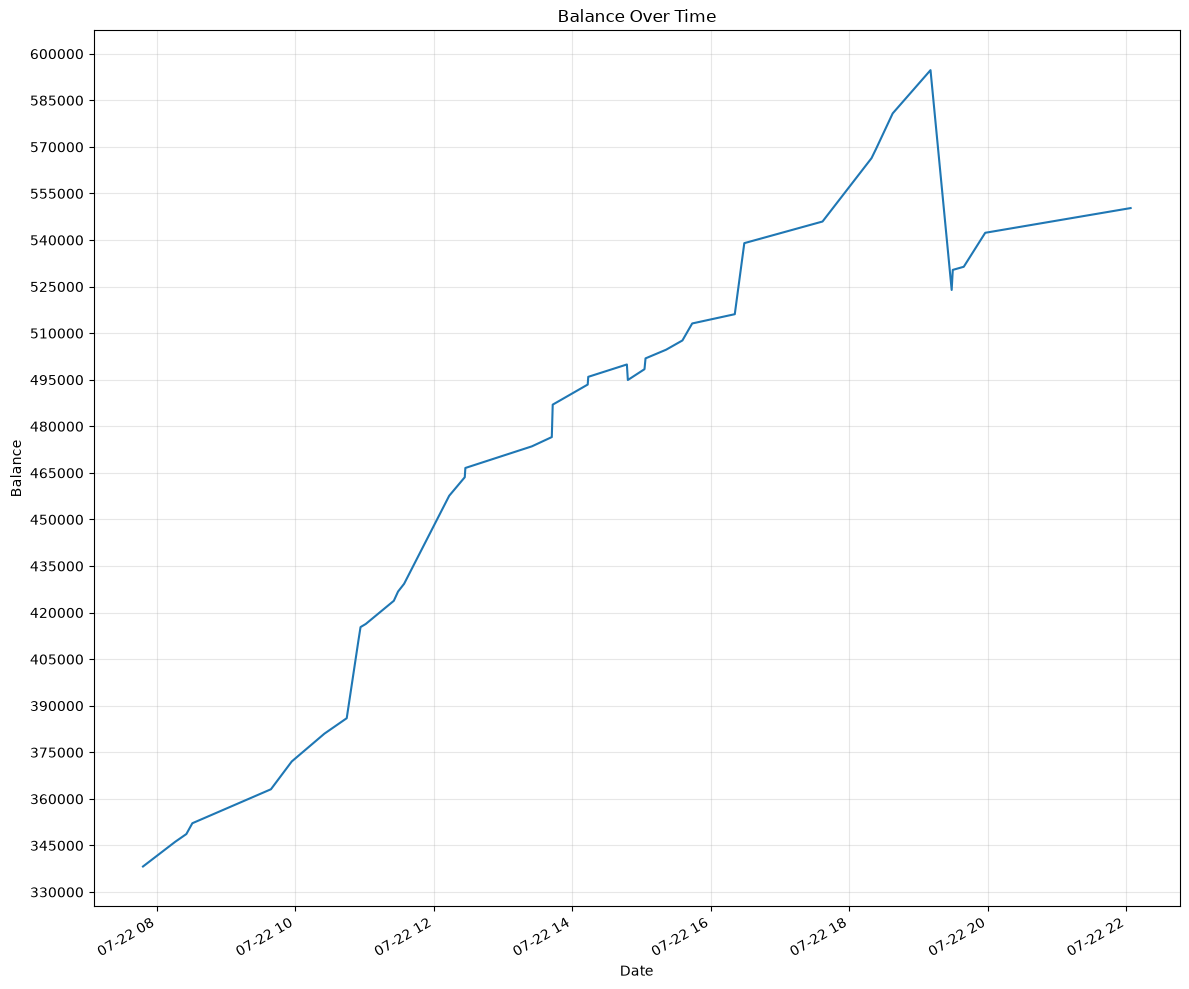

In [11]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import pandas as pd

# Convert the date column to datetime (adjust 'Date' to your actual column name)
df_subset['Date'] = pd.to_datetime(df_subset['Date'])

# Sort by date so the line plots in chronological order
df_subset = df_subset.sort_values('Date')

plt.figure(figsize=(12, 10))
plt.plot(df_subset['Date'], df_subset['Balance'])
plt.title('Balance Over Time')
plt.xlabel('Date')
plt.ylabel('Balance')
plt.grid(True, alpha=0.3)

plt.gca().yaxis.set_major_locator(ticker.MaxNLocator(nbins=20))

plt.gcf().autofmt_xdate()  # rotates and aligns the date labels nicely
plt.tight_layout()
plt.show()